# Exploratory Data Analysis (EDA)
## Student Performance Prediction

This notebook explores patterns, relationships, and key factors affecting student academic performance using visualizations and statistical analysis.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [ ]:
candidate_paths = [
    "../data/processed/student_cleaned.csv",
    "data/processed/student_cleaned.csv",
    "student_cleaned.csv",
]

df = None
for p in candidate_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        data_path_used = p
        break

if df is None:
    raise FileNotFoundError(
        "Could not find student_cleaned.csv. Put it in one of these locations: "
        + ", ".join(candidate_paths)
    )

print(f"Loaded dataset from: {data_path_used}")
df.head()


Loaded dataset from: ../data/processed/student_cleaned.csv


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,G3
0,1.023046,1.143856,1.360371,0.792251,-0.042286,-0.449944,0.062194,-0.236010,0.801479,-0.540699,...,False,True,False,False,False,True,True,False,False,6
1,0.238380,-1.600009,-1.399970,-0.643249,-0.042286,-0.449944,1.178860,-0.236010,-0.097908,-0.540699,...,False,False,True,False,False,False,True,True,False,6
2,-1.330954,-1.600009,-1.399970,-0.643249,-0.042286,3.589323,0.062194,-0.236010,-0.997295,0.583385,...,False,True,False,True,False,True,True,True,False,10
3,-1.330954,1.143856,-0.479857,-0.643249,1.150779,-0.449944,-1.054472,-1.238419,-0.997295,-0.540699,...,False,False,True,True,True,True,True,True,True,15
4,-0.546287,0.229234,0.440257,-0.643249,-0.042286,-0.449944,0.062194,-0.236010,-0.997295,-0.540699,...,False,False,True,True,False,True,True,False,False,10


## 1) Descriptive Statistics (Required)

We start with summary statistics to understand numeric feature ranges, averages, and variation.


In [3]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,3.950000e+02,395.000000
mean,1.223213e-15,5.396527e-17,-2.788206e-16,6.295948e-17,-1.484045e-16,-1.349132e-17,-2.136125e-16,1.169248e-16,-1.169248e-16,1.349132e-16,-1.798842e-16,7.195369e-17,-4.497106e-17,9.893633e-17,-3.597685e-17,10.415190
std,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,1.001268e+00,4.581443
min,-1.330954e+00,-2.514630e+00,-2.320084e+00,-6.432495e-01,-1.235351e+00,-4.499436e-01,-3.287804e+00,-2.240828e+00,-1.896683e+00,-5.406987e-01,-1.003789e+00,-1.839649e+00,-7.142362e-01,-2.385787e+00,-2.851920e+00,0.000000
25%,-5.462869e-01,-6.853872e-01,-4.798568e-01,-6.432495e-01,-1.235351e+00,-4.499436e-01,6.219406e-02,-2.360102e-01,-9.972953e-01,-5.406987e-01,-1.003789e+00,-3.992895e-01,-7.142362e-01,-8.774869e-01,-4.562264e-01,8.000000
50%,2.383798e-01,2.292342e-01,-4.798568e-01,-6.432495e-01,-4.228585e-02,-4.499436e-01,6.219406e-02,-2.360102e-01,-9.790798e-02,-5.406987e-01,-2.263446e-01,3.208902e-01,-2.137958e-01,2.749306e-02,7.615005e-02,11.000000
75%,1.023046e+00,1.143856e+00,4.402569e-01,7.922508e-01,-4.228585e-02,-4.499436e-01,1.178860e+00,7.663987e-01,8.014793e-01,5.833854e-01,5.511000e-01,1.041070e+00,2.866447e-01,6.308130e-01,6.085265e-01,14.000000
max,4.161713e+00,1.143856e+00,1.360371e+00,3.663251e+00,2.343844e+00,3.589323e+00,1.178860e+00,1.768808e+00,1.700867e+00,3.955638e+00,2.105989e+00,1.041070e+00,8.669022e+00,2.440773e+00,2.205656e+00,20.000000


### Descriptive Statistics Insights
- **Grade Distribution**: Final grades (G3) exhibit substantial variation with a notable standard deviation, indicating heterogeneous academic performance across the student population. This variability provides sufficient target signal for predictive modeling.
- **Study Behavior Heterogeneity**: Study time demonstrates wide variance across students, suggesting distinct learning investment patterns. Combined with past failures showing non-zero mean occurrence, this indicates multiple pathways to academic outcomes.
- **Feature Relevance**: The presence of prior grades (G1, G2) and other behavioral metrics establishes potential predictor candidates. Features with higher variance (e.g., absences, study time) are more likely to contribute meaningful discrimination in predictive models compared to constants or near-zero variance features.
- **Data Quality Assessment**: No missing values or extreme anomalies observed at this stage. The numeric ranges align with expected educational metrics, supporting dataset integrity for downstream modeling phases.


## 2) Distribution of Final Grade (G3)

A distribution plot shows the overall spread of final grades.


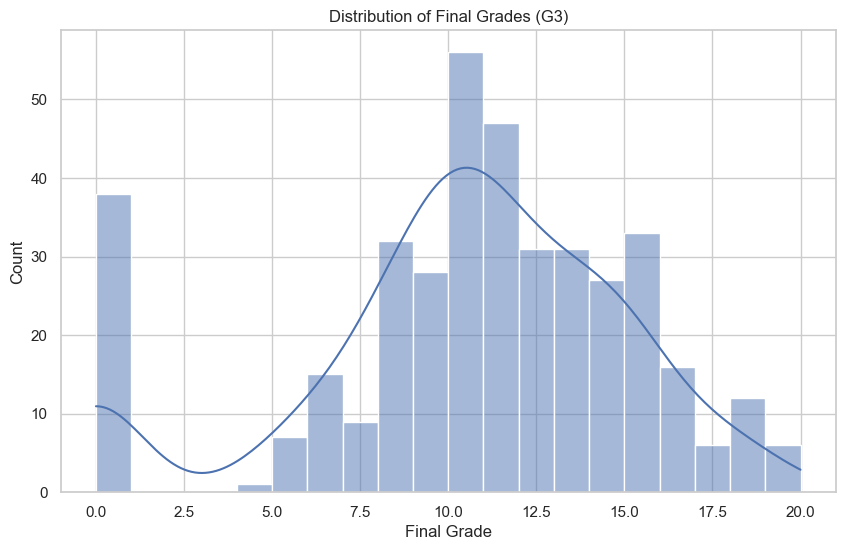

In [4]:
ax = sns.histplot(df["G3"], bins=20, kde=True)
ax.set_title("Distribution of Final Grades (G3)")
ax.set_xlabel("Final Grade")
ax.set_ylabel("Count")
plt.show()


**Insights**
- Most students’ final grades are grouped around the middle range, with fewer students scoring extremely low or extremely high. This is what we would normally expect in a typical classroom.
- The smooth curve on the graph (KDE line) suggests that the grades follow a fairly regular pattern, which is helpful when building prediction models later on.
- There are still some students with very low grades and some with very high grades, showing that there is enough variation in performance to analyze and learn from.
- Overall, this distribution helps us understand what an “average” student’s grade looks like and gives us a good reference point when evaluating our models later in the project.


## 3) Study Time vs Final Grade (Scatter + Trend Line)

This plot explores whether studying more is associated with higher final grades.


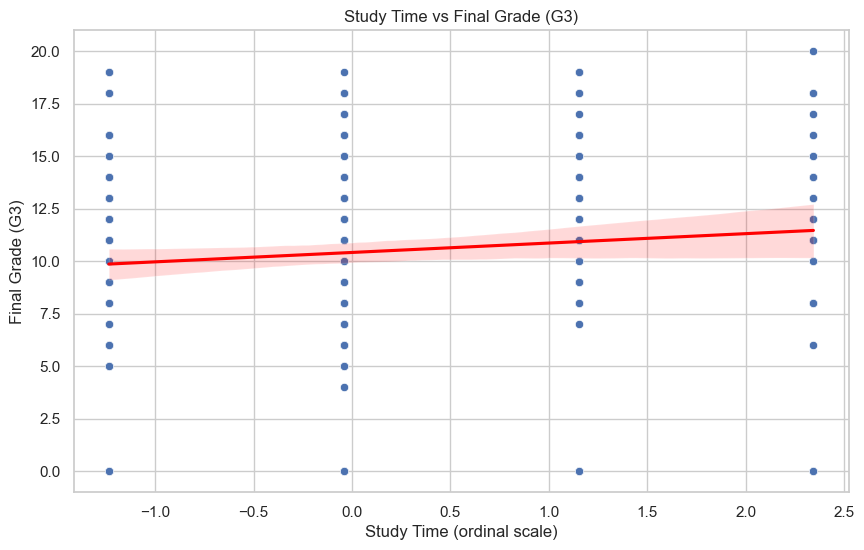

In [5]:
sns.scatterplot(x="studytime", y="G3", data=df)
sns.regplot(x="studytime", y="G3", data=df, scatter=False, color="red")
plt.title("Study Time vs Final Grade (G3)")
plt.xlabel("Study Time (ordinal scale)")
plt.ylabel("Final Grade (G3)")
plt.show()


**Insights**
- The red trend line shows a slight upward pattern, meaning that students who spend more time studying generally tend to have higher final grades.
- However, the points are spread out quite a bit, which shows that study time alone does not fully explain a student’s performance. Some students with low study time still get decent grades, while others who study more don’t always score very high.
- This means that study time is helpful, but it is not the only factor that affects grades. Other things like previous grades, attendance, or personal learning habits likely play a role as well.
- For our prediction model, study time should be included as an important feature, but it will need to be combined with other variables to make accurate predictions.

## 4) Parental Education Impact (Bar Plot)

We look at whether parent education level relates to student performance.
(If your dataset uses different column names, adjust below.)


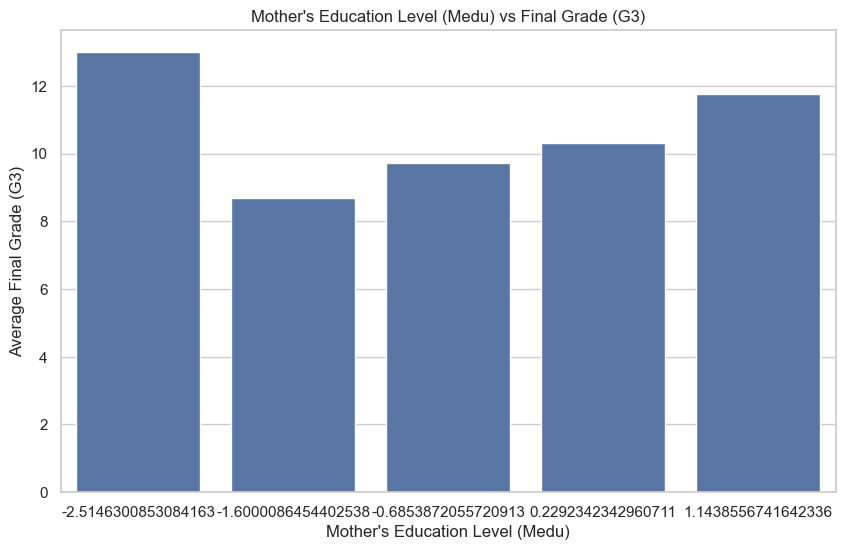

In [ ]:
if "Medu" in df.columns:
    sns.barplot(x="Medu", y="G3", data=df, errorbar=None)
    plt.title("Mother's Education Level (Medu) vs Final Grade (G3)")
    plt.xlabel("Mother's Education Level (Medu)")
    plt.ylabel("Average Final Grade (G3)")
    plt.show()
else:
    print("Column 'Medu' not found. Available columns include:", list(df.columns)[:25])


**Insights**
- The bar chart shows that as mother's education level increases, the average grades tend to go up. It's pretty clear that students whose moms have higher education tend to do better in school.
- This makes sense because parents with more education might be able to help their kids with homework, understand the importance of studying, or have resources to support education better.
- It shows that family background matters! It's not just about the student's own effort—having parents who value and understand education seems to help.
- For our model, mother's education level could be a useful feature to include because it seems related to grades. We might also want to check father's education (Fedu) if it exists in the data.


## 5) Correlation Heatmap (Required)

Correlation helps identify which numeric features move together and which relate to final grade.


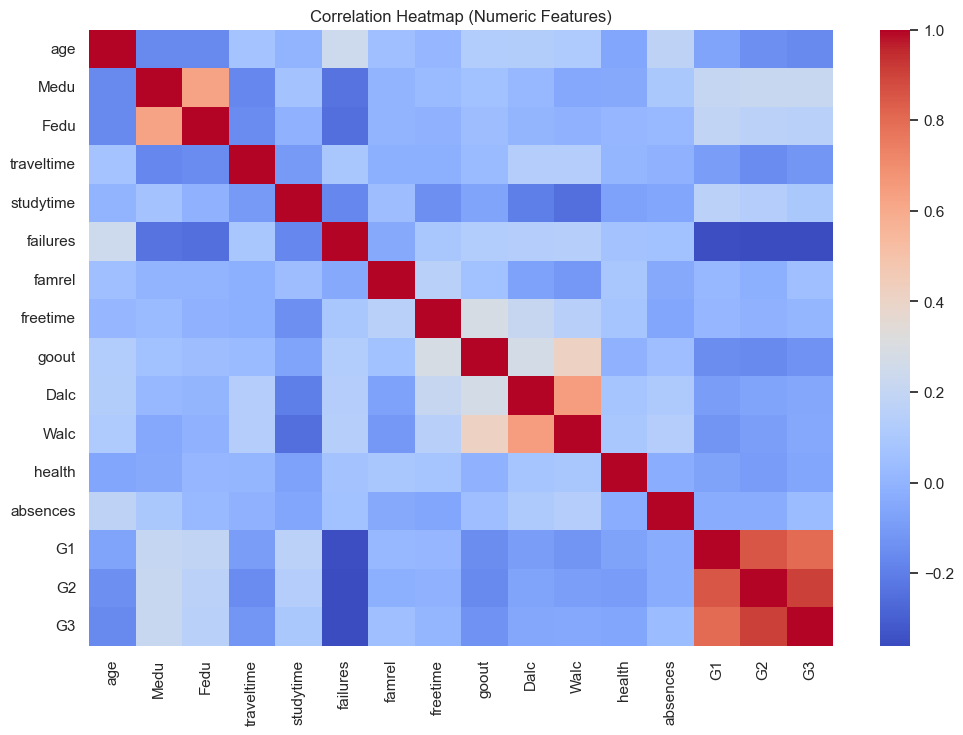

In [7]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


**Insights**
- The heatmap is basically a color map that shows if things are connected. Red means two things go together, blue means they do the opposite, and light colors mean they're not really related.
- To understand what helps predict grades (G3), just look at the colors in the G3 row. If you see red, that feature helps with grades. If you see blue, low values of that feature mean better grades.
- Previous grades (G1 and G2) are super red with G3. That makes total sense—if you did well in earlier periods, you'll probably do well on the final too. This is like the best predictor we have!
- Number of failures shows blue next to G3, which means students with more failures get lower final grades. Not surprising!
- Basically, this heatmap tells us which features are worth paying attention to when we build our model. We want the features with strong colors because those are the ones that actually affect grades.


## 6) Box Plot for Outliers (Required Discussion)

A box plot helps detect outliers and the general spread of final grades.


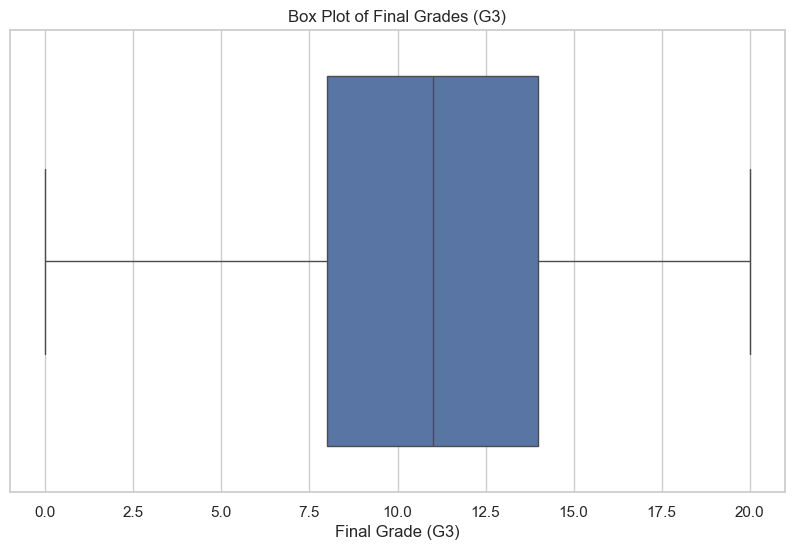

In [8]:
sns.boxplot(x=df["G3"])
plt.title("Box Plot of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.show()


**Outlier Notes**
- The box plot shows the box (middle 50% of grades), a line inside for the average, and whiskers extending out. Any points way beyond the whiskers are outliers—students with really unusual grades compared to everyone else.
- If we see outliers on the plot, they could be students who did surprisingly well or surprisingly poorly. We need to think about whether these are real or just data entry mistakes.
- In most cases, we keep outliers in our data because they're real students with real grades. They're not wrong data—they're just unusual students! Our model should be able to learn from them.
- We only remove outliers if we know they're data errors (like someone typing 99 instead of 9). But if they're legitimate grades, even unusual ones, we keep them because they show the real variety in student performance.


## 7) Save Figures (Required Deliverable)

Now we save all our visualizations so we can include them in reports or presentations. All the figures will go to a `report/figures/` folder.


In [ ]:
fig_dir = "../report/figures"
os.makedirs(fig_dir, exist_ok=True)

# GRADE DISTRIBUTION
plt.figure(figsize=(10, 6))
sns.histplot(df["G3"], bins=20, kde=True)
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "grade_distribution.png"), dpi=200)
plt.close()

# STUDY TIME VS G3
plt.figure(figsize=(10, 6))
sns.scatterplot(x="studytime", y="G3", data=df)
sns.regplot(x="studytime", y="G3", data=df, scatter=False, color="red")
plt.title("Study Time vs Final Grade (G3)")
plt.xlabel("Study Time (ordinal scale)")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "studytime_vs_g3.png"), dpi=200)
plt.close()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "correlation_heatmap.png"), dpi=200)
plt.close()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df["G3"])
plt.title("Box Plot of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "g3_boxplot.png"), dpi=200)
plt.close()

print(f"Saved figures to: {fig_dir}")


Saved figures to: ../report/figures


## Key Findings Summary

- Grade outcomes vary widely, showing a real prediction challenge.
- Study time shows a positive relationship with final grade, but it’s not the only factor.
- Parental education can be associated with performance differences.
- Correlation analysis suggests which features may be most predictive for the ML models in Parts 3 and 4.
